In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Sensor Logs- Already in IST

In [2]:
logs = pd.read_json('gurvivek_system_logs.jsonl', lines = True)

In [3]:
logs["timestamp"] = pd.to_datetime(logs["timestamp"]).dt.tz_localize("Asia/Kolkata")

In [4]:
logs.head()     # This is in IST Format only

,timestamp,cpuUsage,cpuTemperature,cpuPackagePower,cpuVoltageCore1,cpuAverageClock,cpuEfficiencyAverageClock,cpuFactors,virtualMemoryUsage,totalMemoryUsage,...,gpuHotspotTemperature,gpuCoreLoad,gpuCoreVoltage,gpuPackagePower,gpuCoreClock,gpuMemoryClock,gpuMemoryLoad,ssdCompositeTemperature,networkConnections,processCount
0,2026-07-14 08:29:30.858070200+05:30,12.2,84.8,18.4,0.18,3786,465,"[43.75, 44.0, 44.0, 43.75, 29.17, 43.75, 29.17...",59.0,88.1,...,73.3,0,0.81,8.1,1485,5871,3.3,0,254,299
1,2026-07-14 08:29:37.893594900+05:30,22.5,93.8,28.9,0.18,3286,874,"[44.0, 44.25, 29.5, 29.5, 29.5, 29.5, 29.5, 29.5]",59.2,88.5,...,73.8,0,0.81,8.2,1485,5871,3.3,55,253,299
2,2026-07-14 08:29:39.944338900+05:30,12.6,87.9,20.9,0.16,3237,489,"[44.5, 44.25, 29.5, 29.5, 29.5, 29.5, 29.5, 29.5]",59.2,88.5,...,73.7,0,0.81,8.5,1485,5871,3.3,55,254,299
3,2026-07-14 08:29:41.981299800+05:30,9.8,85.3,18.5,0.11,3162,373,"[31.75, 45.25, 30.17, 30.17, 30.17, 30.17, 30....",59.3,88.3,...,73.8,0,0.81,8.4,1485,5871,3.3,55,258,299
4,2026-07-14 08:29:44.023546200+05:30,16.9,86.4,22.0,0.11,3283,600,"[44.75, 45.0, 30.0, 30.17, 30.17, 30.17, 30.17...",59.2,88.3,...,73.8,0,0.81,3.1,1485,5871,3.3,55,259,299


# Load Stress Events - UTC Format (Z)

In [5]:
events = pd.read_json("gurvivek_stress_events.jsonl", lines = True)

In [6]:
events["startTime"] = pd.to_datetime(events["startTime"], utc= True).dt.tz_convert("Asia/Kolkata")
events["endTime"] = pd.to_datetime(events["endTime"], utc= True).dt.tz_convert("Asia/Kolkata")


In [7]:
events.head()

,eventType,runId,deviceId,mode,targetLoad,gpuTargetLoad,stepNumber,startTime,endTime,actualDurationSeconds,seed,message
0,RUN_START,GURVIVEK_2026-07-14T03-05-27-359989900Z,GURVIVEK,SYSTEM,0,-1,0,2026-07-14 08:35:29.533647+05:30,2026-07-14 08:35:29.533647+05:30,0,101,Automatic stress experiment started.
1,SESSION,GURVIVEK_2026-07-14T03-05-27-359989900Z,GURVIVEK,INITIAL_IDLE,0,-1,0,2026-07-14 08:35:29.537589800+05:30,2026-07-14 08:37:29.549395+05:30,120,101,Idle or cooling session completed.
2,WORKLOAD_STEP,GURVIVEK_2026-07-14T03-05-27-359989900Z,GURVIVEK,RAMP,0,-1,1,2026-07-14 08:37:29.586530+05:30,2026-07-14 08:38:48.588721500+05:30,79,101,Completed workload step.
3,WORKLOAD_STEP,GURVIVEK_2026-07-14T03-05-27-359989900Z,GURVIVEK,RAMP,0,-1,2,2026-07-14 08:38:48.590224500+05:30,2026-07-14 08:39:54.592235600+05:30,66,101,Completed workload step.
4,WORKLOAD_STEP,GURVIVEK_2026-07-14T03-05-27-359989900Z,GURVIVEK,RAMP,20,-1,3,2026-07-14 08:39:54.592235600+05:30,2026-07-14 08:43:45.594185300+05:30,231,101,Completed workload step.


In [8]:
logs["timestamp"] = pd.to_datetime(logs["timestamp"])

events["startTime"] = pd.to_datetime(events["startTime"])
events["endTime"] = pd.to_datetime(events["endTime"])


In [9]:
logs = logs.sort_values("timestamp").reset_index(drop=True)
events = events.sort_values("startTime").reset_index(drop=True)

In [10]:
logs.head()

,timestamp,cpuUsage,cpuTemperature,cpuPackagePower,cpuVoltageCore1,cpuAverageClock,cpuEfficiencyAverageClock,cpuFactors,virtualMemoryUsage,totalMemoryUsage,...,gpuHotspotTemperature,gpuCoreLoad,gpuCoreVoltage,gpuPackagePower,gpuCoreClock,gpuMemoryClock,gpuMemoryLoad,ssdCompositeTemperature,networkConnections,processCount
0,2026-07-14 08:29:30.858070200+05:30,12.2,84.8,18.4,0.18,3786,465,"[43.75, 44.0, 44.0, 43.75, 29.17, 43.75, 29.17...",59.0,88.1,...,73.3,0,0.81,8.1,1485,5871,3.3,0,254,299
1,2026-07-14 08:29:37.893594900+05:30,22.5,93.8,28.9,0.18,3286,874,"[44.0, 44.25, 29.5, 29.5, 29.5, 29.5, 29.5, 29.5]",59.2,88.5,...,73.8,0,0.81,8.2,1485,5871,3.3,55,253,299
2,2026-07-14 08:29:39.944338900+05:30,12.6,87.9,20.9,0.16,3237,489,"[44.5, 44.25, 29.5, 29.5, 29.5, 29.5, 29.5, 29.5]",59.2,88.5,...,73.7,0,0.81,8.5,1485,5871,3.3,55,254,299
3,2026-07-14 08:29:41.981299800+05:30,9.8,85.3,18.5,0.11,3162,373,"[31.75, 45.25, 30.17, 30.17, 30.17, 30.17, 30....",59.3,88.3,...,73.8,0,0.81,8.4,1485,5871,3.3,55,258,299
4,2026-07-14 08:29:44.023546200+05:30,16.9,86.4,22.0,0.11,3283,600,"[44.75, 45.0, 30.0, 30.17, 30.17, 30.17, 30.17...",59.2,88.3,...,73.8,0,0.81,3.1,1485,5871,3.3,55,259,299


In [11]:
events.head()

,eventType,runId,deviceId,mode,targetLoad,gpuTargetLoad,stepNumber,startTime,endTime,actualDurationSeconds,seed,message
0,RUN_START,GURVIVEK_2026-07-14T03-05-27-359989900Z,GURVIVEK,SYSTEM,0,-1,0,2026-07-14 08:35:29.533647+05:30,2026-07-14 08:35:29.533647+05:30,0,101,Automatic stress experiment started.
1,RUN,GURVIVEK_2026-07-14T03-05-27-359989900Z,GURVIVEK,COMPLETE_EXPERIMENT,0,-1,0,2026-07-14 08:35:29.533647+05:30,2026-07-14 16:47:29.694697+05:30,29520,101,Experiment completed normally.
2,SESSION,GURVIVEK_2026-07-14T03-05-27-359989900Z,GURVIVEK,INITIAL_IDLE,0,-1,0,2026-07-14 08:35:29.537589800+05:30,2026-07-14 08:37:29.549395+05:30,120,101,Idle or cooling session completed.
3,SESSION,GURVIVEK_2026-07-14T03-05-27-359989900Z,GURVIVEK,RAMP,0,-1,51,2026-07-14 08:37:29.561353900+05:30,2026-07-14 09:51:29.563234500+05:30,4440,101,Workload session completed.
4,WORKLOAD_STEP,GURVIVEK_2026-07-14T03-05-27-359989900Z,GURVIVEK,RAMP,0,-1,1,2026-07-14 08:37:29.586530+05:30,2026-07-14 08:38:48.588721500+05:30,79,101,Completed workload step.


In [12]:
print("Sensor start:", logs["timestamp"].min())
print("Sensor end:  ", logs["timestamp"].max())


Sensor start: 2026-07-14 08:29:30.858070200+05:30
Sensor end:   2026-07-14 17:15:59.243815+05:30


In [13]:
print("\nEvent start:", events["startTime"].min())
print("Event end:  ", events["endTime"].max())


Event start: 2026-07-14 08:35:29.533647+05:30
Event end:   2026-07-14 16:47:29.694697+05:30


In [14]:
print("Sensor timezone:", logs["timestamp"].dt.tz)
print("Event timezone:", events["startTime"].dt.tz)

Sensor timezone: Asia/Kolkata
Event timezone: Asia/Kolkata


In [15]:
print(events.head(10).to_string())

print("\nUnique event types:")
if "eventType" in events.columns:
    print(events["eventType"].value_counts())

print("\nUnique modes:")
if "mode" in events.columns:
    print(events["mode"].value_counts())

       eventType                                    runId  deviceId                 mode  targetLoad  gpuTargetLoad  stepNumber                           startTime                             endTime  actualDurationSeconds  seed                               message
0      RUN_START  GURVIVEK_2026-07-14T03-05-27-359989900Z  GURVIVEK               SYSTEM           0             -1           0    2026-07-14 08:35:29.533647+05:30    2026-07-14 08:35:29.533647+05:30                      0   101  Automatic stress experiment started.
1            RUN  GURVIVEK_2026-07-14T03-05-27-359989900Z  GURVIVEK  COMPLETE_EXPERIMENT           0             -1           0    2026-07-14 08:35:29.533647+05:30    2026-07-14 16:47:29.694697+05:30                  29520   101        Experiment completed normally.
2        SESSION  GURVIVEK_2026-07-14T03-05-27-359989900Z  GURVIVEK         INITIAL_IDLE           0             -1           0 2026-07-14 08:35:29.537589800+05:30    2026-07-14 08:37:29.549395+05:30

# Cleaning the Stress Intervals

In [16]:
# Keep events that have a valid time interval
intervals = events[
    events["startTime"].notna() &
    events["endTime"].notna()
].copy()

# Remove invalid intervals
intervals = intervals[
    intervals["endTime"] > intervals["startTime"]
].copy()
intervals = intervals.sort_values("startTime").reset_index(drop=True)
print("Usable intervals:", len(intervals))

display(
    intervals[
        [
            col for col in [
                "startTime",
                "endTime",
                "mode",
                "targetLoad",
                "stepNumber",
                "eventType"
            ]
            if col in intervals.columns
        ]
    ].head(20)
)


Usable intervals: 304


,startTime,endTime,mode,targetLoad,stepNumber,eventType
0,2026-07-14 08:35:29.533647+05:30,2026-07-14 16:47:29.694697+05:30,COMPLETE_EXPERIMENT,0,0,RUN
1,2026-07-14 08:35:29.537589800+05:30,2026-07-14 08:37:29.549395+05:30,INITIAL_IDLE,0,0,SESSION
2,2026-07-14 08:37:29.561353900+05:30,2026-07-14 09:51:29.563234500+05:30,RAMP,0,51,SESSION
3,2026-07-14 08:37:29.586530+05:30,2026-07-14 08:38:48.588721500+05:30,RAMP,0,1,WORKLOAD_STEP
4,2026-07-14 08:38:48.590224500+05:30,2026-07-14 08:39:54.592235600+05:30,RAMP,0,2,WORKLOAD_STEP
5,2026-07-14 08:39:54.592235600+05:30,2026-07-14 08:43:45.594185300+05:30,RAMP,20,3,WORKLOAD_STEP
6,2026-07-14 08:43:45.594185300+05:30,2026-07-14 08:44:23.596501800+05:30,RAMP,20,4,WORKLOAD_STEP
7,2026-07-14 08:44:23.596501800+05:30,2026-07-14 08:47:38.598472+05:30,RAMP,40,5,WORKLOAD_STEP
8,2026-07-14 08:47:38.598472+05:30,2026-07-14 08:50:03.601614+05:30,RAMP,40,6,WORKLOAD_STEP
9,2026-07-14 08:50:03.602870700+05:30,2026-07-14 08:50:31.604247800+05:30,RAMP,60,7,WORKLOAD_STEP


In [17]:
# ============================================================
# BUILD CLEAN INTERVAL TABLES
# ============================================================

# Detailed workload intervals
workload_steps = events[
    events["eventType"] == "WORKLOAD_STEP"
].copy()

# Idle and cooling intervals
session_intervals = events[
    (events["eventType"] == "SESSION") &
    (
        (events["mode"] == "INITIAL_IDLE") |
        (events["mode"].str.contains("COOLING", na=False))
    )
].copy()


print("Workload steps:", len(workload_steps))
print("Idle/cooling sessions:", len(session_intervals))

print("\nWorkload modes:")
print(workload_steps["mode"].value_counts())

print("\nNon-workload sessions:")
print(session_intervals["mode"].value_counts())

Workload steps: 286
Idle/cooling sessions: 9

Workload modes:
mode
MIXED               98
RAMP                51
GPU_CPU_COMBINED    49
TRANSITION          49
CHAOS               39
Name: count, dtype: int64

Non-workload sessions:
mode
INITIAL_IDLE                        1
COOLING_AFTER_RAMP                  1
COOLING_AFTER_GPU_CPU_COMBINED_1    1
COOLING_AFTER_CHAOS                 1
COOLING_AFTER_GPU_CPU_COMBINED_2    1
COOLING_AFTER_TRANSITION            1
COOLING_AFTER_GPU_CPU_COMBINED_3    1
COOLING_AFTER_MIXED                 1
FINAL_COOLING                       1
Name: count, dtype: int64


In [18]:
import numpy as np

In [19]:
merged = logs.copy()

merged["mode"] = "UNASSIGNED"
merged["targetLoad"] = np.nan
merged["gpuTargetLoad"] = np.nan
merged["stepNumber"] = np.nan
merged["eventType"] = None


# ===============
# =============================================
# 1. ASSIGN IDLE AND COOLING SESSIONS
# ============================================================

for _, event in session_intervals.iterrows():

    mask = (
        (merged["timestamp"] >= event["startTime"]) &
        (merged["timestamp"] < event["endTime"])
    )

    merged.loc[mask, "mode"] = event["mode"]
    merged.loc[mask, "targetLoad"] = 0
    merged.loc[mask, "gpuTargetLoad"] = np.nan
    merged.loc[mask, "eventType"] = "SESSION"


# ============================================================
# 2. ASSIGN ACTUAL WORKLOAD STEPS
# ============================================================

for _, event in workload_steps.iterrows():

    mask = (
        (merged["timestamp"] >= event["startTime"]) &
        (merged["timestamp"] < event["endTime"])
    )

    merged.loc[mask, "mode"] = event["mode"]
    merged.loc[mask, "targetLoad"] = event["targetLoad"]
    merged.loc[mask, "gpuTargetLoad"] = event["gpuTargetLoad"]
    merged.loc[mask, "stepNumber"] = event["stepNumber"]
    merged.loc[mask, "eventType"] = "WORKLOAD_STEP"


# ============================================================
# 3. IMPUTE ZERO TEMPERATURE READINGS
# ============================================================

zero_temp_mask = merged["cpuTemperature"] == 0
zero_temp_count = int(zero_temp_mask.sum())

if zero_temp_count > 0:
    merged.loc[zero_temp_mask, "cpuTemperature"] = np.nan
    merged["cpuTemperature"] = (
        merged["cpuTemperature"]
        .interpolate(method="linear")
        .ffill()
        .bfill()
    )
    print(f"Imputed {zero_temp_count} zero-temperature rows.")


Imputed 14 zero-temperature rows.


In [20]:
print("Merged shape:", merged.shape)

print("\nMode distribution:")
print(merged["mode"].value_counts())

print("\nEvent type distribution:")
print(merged["eventType"].value_counts(dropna=False))

print("\nUnassigned samples:")
print((merged["mode"] == "UNASSIGNED").sum())

Merged shape: (15391, 28)

Mode distribution:
mode
MIXED                               4365
GPU_CPU_COMBINED                    2210
RAMP                                2186
CHAOS                               2186
TRANSITION                          2180
UNASSIGNED                           874
FINAL_COOLING                        294
COOLING_AFTER_RAMP                   149
COOLING_AFTER_GPU_CPU_COMBINED_3     149
COOLING_AFTER_GPU_CPU_COMBINED_1     148
COOLING_AFTER_CHAOS                  148
COOLING_AFTER_GPU_CPU_COMBINED_2     148
COOLING_AFTER_TRANSITION             148
COOLING_AFTER_MIXED                  147
INITIAL_IDLE                          59
Name: count, dtype: int64

Event type distribution:
eventType
WORKLOAD_STEP    13127
SESSION           1390
None               874
Name: count, dtype: int64

Unassigned samples:
874


In [21]:
# experiment_start = events.loc[
#     events["eventType"] == "RUN",
#     "startTime"
# ].iloc[0]

# experiment_end = events.loc[
#     events["eventType"] == "RUN",
#     "endTime"
# ].iloc[0]


# merged.loc[
#     merged["timestamp"] < experiment_start,
#     "mode"
# ] = "PRE_EXPERIMENT"


# merged.loc[
#     merged["timestamp"] >= experiment_end,
#     "mode"
# ] = "POST_EXPERIMENT"

In [22]:
merged.to_csv(
    "gurvivek_merged_experiment.csv",
    index=False
)

print("Saved: gurvivek_merged_experiment.csv")

Saved: gurvivek_merged_experiment.csv


In [23]:
import matplotlib.pyplot as plt

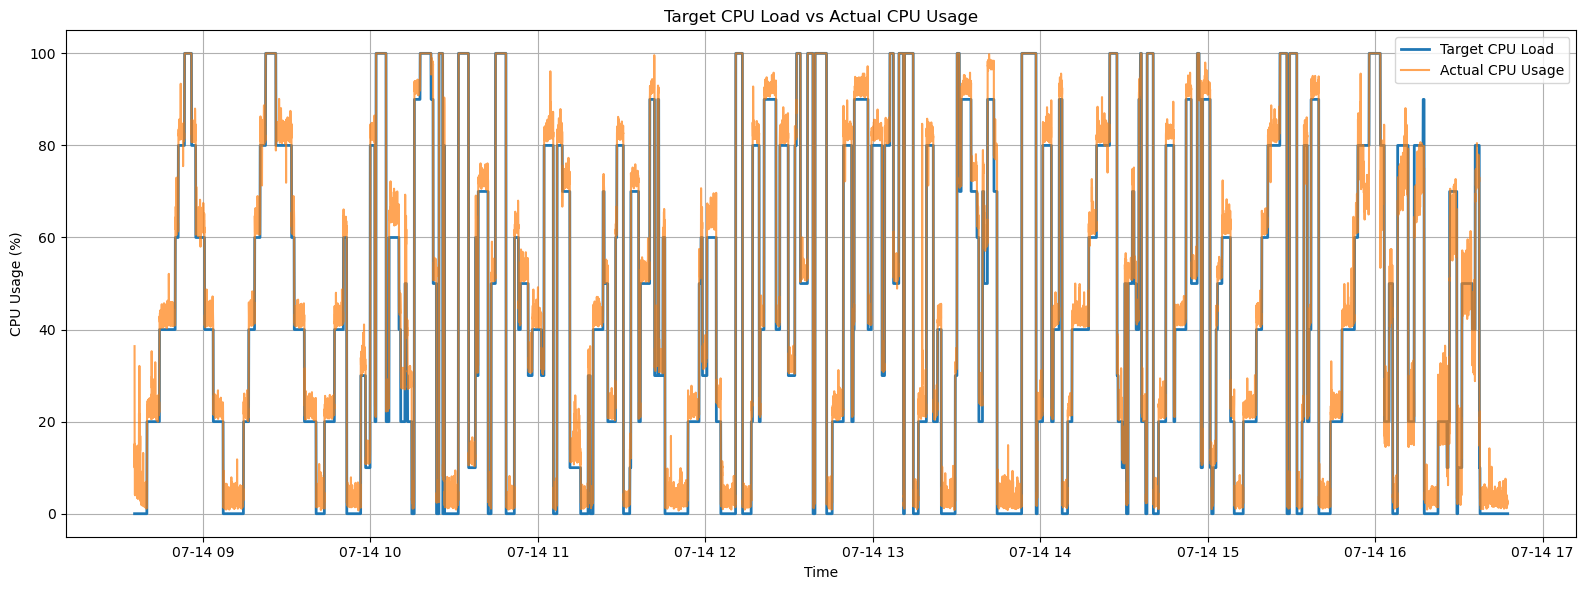

In [24]:
valid_target = merged.dropna(
    subset=["targetLoad", "cpuUsage"]
).copy()

plt.figure(figsize=(16, 6))

plt.plot(
    valid_target["timestamp"],
    valid_target["targetLoad"],
    label="Target CPU Load",
    linewidth=2
)

plt.plot(
    valid_target["timestamp"],
    valid_target["cpuUsage"],
    label="Actual CPU Usage",
    alpha=0.7
)

plt.title("Target CPU Load vs Actual CPU Usage")
plt.xlabel("Time")
plt.ylabel("CPU Usage (%)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [25]:
valid_target["loadError"] = (
    valid_target["cpuUsage"] -
    valid_target["targetLoad"]
)

print(
    "Mean Absolute Load Error:",
    valid_target["loadError"].abs().mean()
)

print(
    "Correlation:",
    valid_target[
        ["targetLoad", "cpuUsage"]
    ].corr().iloc[0, 1]
)

Mean Absolute Load Error: 3.39260866570228
Correlation: 0.9900109517849782


In [26]:
load_summary = (
    valid_target
    .groupby("targetLoad")
    .agg(
        samples=("cpuUsage", "count"),
        meanActualCPU=("cpuUsage", "mean"),
        stdActualCPU=("cpuUsage", "std"),
        meanTemperature=("cpuTemperature", "mean")
    )
    .reset_index()
)

display(load_summary)

,targetLoad,samples,meanActualCPU,stdActualCPU,meanTemperature
0,0.0,3180,3.881572,5.036570,63.270975
1,10.0,399,13.675439,4.063658,86.648622
2,20.0,2117,23.178460,4.132260,96.614856
3,30.0,424,33.871462,5.091514,100.004245
4,40.0,1574,42.760546,2.830665,99.031925
5,50.0,844,52.408294,4.587277,95.156043
6,60.0,850,63.282706,3.826526,95.418353
7,70.0,502,71.559163,6.010472,92.958566
8,80.0,2010,80.337065,6.114139,92.922637
9,90.0,885,92.343955,4.799453,91.346667


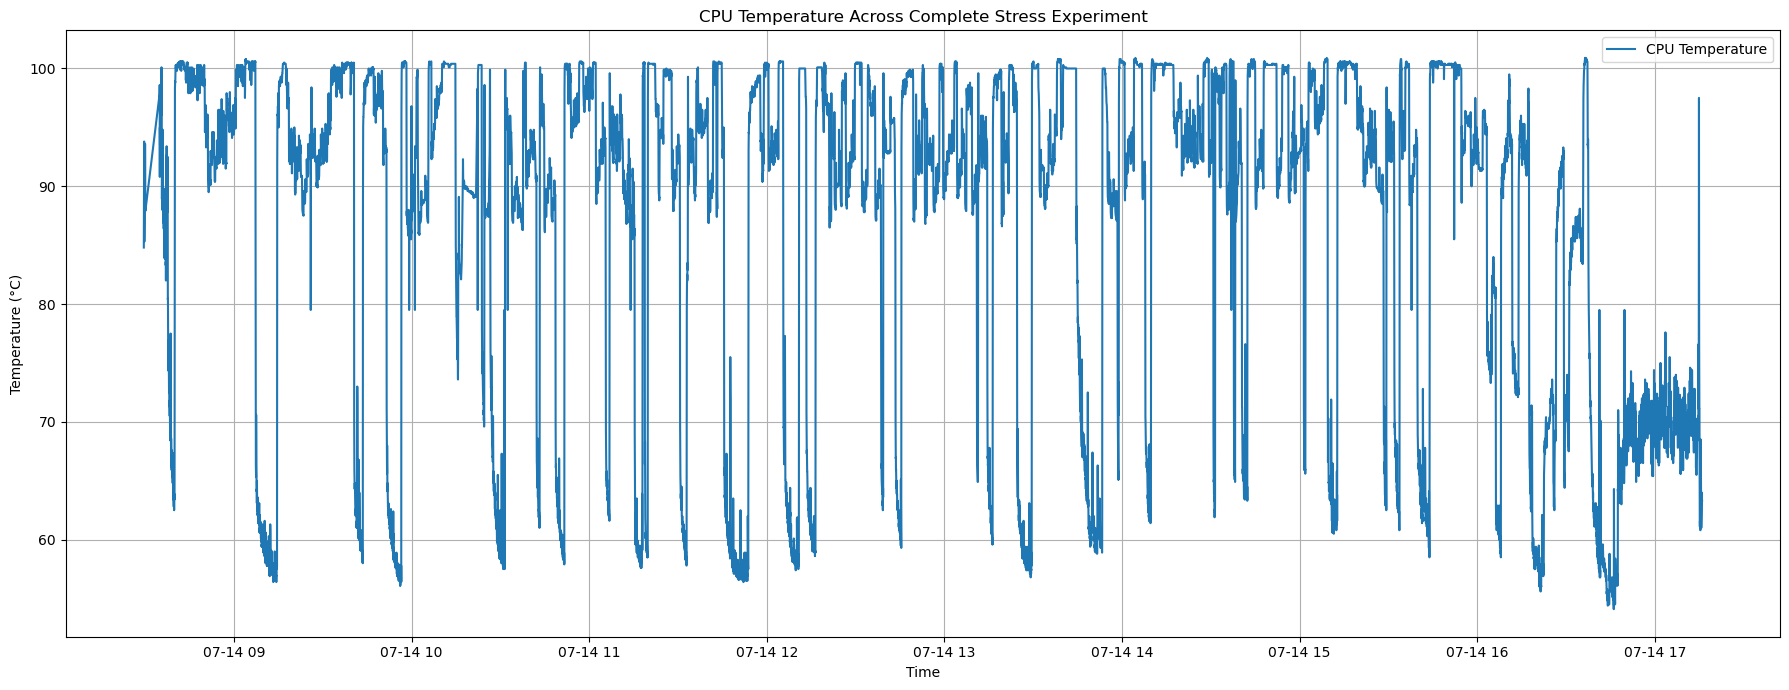

In [27]:
plt.figure(figsize=(18, 7))

plt.plot(
    merged["timestamp"],
    merged["cpuTemperature"],
    label="CPU Temperature"
)

plt.title(
    "CPU Temperature Across Complete Stress Experiment"
)

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [28]:
mode_changes = merged[
    merged["mode"] != merged["mode"].shift()
][
    ["timestamp", "mode"]
]

display(mode_changes)

,timestamp,mode
0,2026-07-14 08:29:30.858070200+05:30,UNASSIGNED
33,2026-07-14 08:35:29.599905600+05:30,INITIAL_IDLE
92,2026-07-14 08:37:29.690753400+05:30,RAMP
2278,2026-07-14 09:51:29.757035500+05:30,COOLING_AFTER_RAMP
2427,2026-07-14 09:56:31.312400200+05:30,GPU_CPU_COMBINED
3308,2026-07-14 10:26:30.610875200+05:30,COOLING_AFTER_GPU_CPU_COMBINED_1
3456,2026-07-14 10:31:30.283504500+05:30,CHAOS
5642,2026-07-14 11:45:30.283935100+05:30,COOLING_AFTER_CHAOS
5790,2026-07-14 11:50:29.871500400+05:30,GPU_CPU_COMBINED
6235,2026-07-14 12:05:31.297032+05:30,COOLING_AFTER_GPU_CPU_COMBINED_2


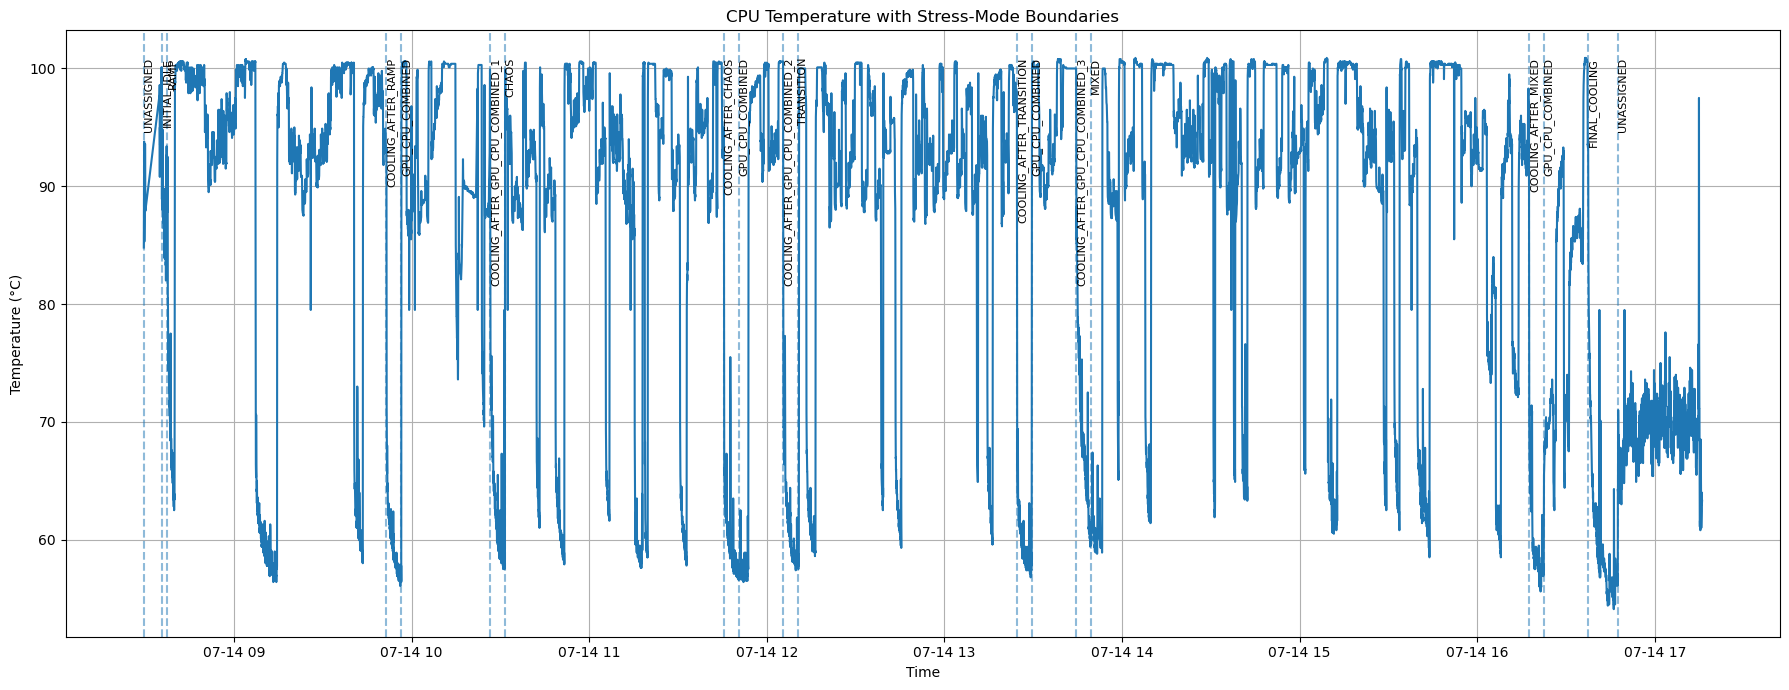

In [29]:
plt.figure(figsize=(18, 7))

plt.plot(
    merged["timestamp"],
    merged["cpuTemperature"],
    label="CPU Temperature"
)

for _, row in mode_changes.iterrows():

    plt.axvline(
        row["timestamp"],
        linestyle="--",
        alpha=0.5
    )

    plt.text(
        row["timestamp"],
        merged["cpuTemperature"].max(),
        str(row["mode"]),
        rotation=90,
        verticalalignment="top",
        fontsize=8
    )

plt.title(
    "CPU Temperature with Stress-Mode Boundaries"
)

plt.xlabel("Time")
plt.ylabel("Temperature (°C)")

plt.grid(True)
plt.tight_layout()
plt.show()

In [30]:
# Correlate every numeric sensor and workload target with both temperatures.
# Pearson captures linear relationships; Spearman captures monotonic ones.
temperature_targets = ["cpuTemperature", "gpuTemperature"]
numeric_features = merged.select_dtypes(include="number").columns.tolist()
feature_columns = [
    col for col in numeric_features
    if col not in temperature_targets + ["stepNumber"]
]

pearson_correlations = merged[feature_columns + temperature_targets].corr(method="pearson")
spearman_correlations = merged[feature_columns + temperature_targets].corr(method="spearman")

correlation_summary = (
    pd.DataFrame({
        "pearson_cpuTemperature": pearson_correlations["cpuTemperature"].drop("cpuTemperature"),
        "spearman_cpuTemperature": spearman_correlations["cpuTemperature"].drop("cpuTemperature"),
        "pearson_gpuTemperature": pearson_correlations["gpuTemperature"].drop("gpuTemperature"),
        "spearman_gpuTemperature": spearman_correlations["gpuTemperature"].drop("gpuTemperature"),
    })
    .drop(index=["gpuTemperature", "cpuTemperature"], errors="ignore")
)
correlation_summary["max_abs_pearson"] = correlation_summary[
    ["pearson_cpuTemperature", "pearson_gpuTemperature"]
].abs().max(axis=1)
correlation_summary = correlation_summary.sort_values("max_abs_pearson", ascending=False)

display(correlation_summary.round(3))

# Dedicated efficiency-clock correlations requested for CPU frequency analysis.
efficiency_clock_pairs = [
    ("cpuEfficiencyAverageClock", "cpuAverageClock", "Average CPU Clock"),
    ("cpuEfficiencyAverageClock", "cpuVoltageCore1", "CPU Core 1 Voltage"),
]
efficiency_clock_correlation = pd.DataFrame([
    {
        "feature": label,
        "pearsonCorrelation": merged[[efficiency_col, feature_col]].corr(method="pearson").iloc[0, 1],
        "spearmanCorrelation": merged[[efficiency_col, feature_col]].corr(method="spearman").iloc[0, 1],
    }
    for efficiency_col, feature_col, label in efficiency_clock_pairs
])
display(efficiency_clock_correlation.round(3))


,pearson_cpuTemperature,spearman_cpuTemperature,pearson_gpuTemperature,spearman_gpuTemperature,max_abs_pearson
gpuCoreTemperature,0.521,0.470,1.000,1.000,1.000
gpuHotspotTemperature,0.514,0.461,0.998,0.986,0.998
cpuPackagePower,0.899,0.512,0.368,0.558,0.899
gpuCoreLoad,0.156,0.092,0.758,0.345,0.758
gpuPackagePower,0.110,0.297,0.743,0.689,0.743
gpuTargetLoad,0.099,-0.023,0.707,0.214,0.707
cpuEfficiencyAverageClock,0.636,0.397,0.393,0.654,0.636
cpuUsage,0.578,0.378,0.406,0.666,0.578
targetLoad,0.532,0.262,0.371,0.621,0.532
gpuMemoryClock,-0.112,-0.045,0.383,0.059,0.383


,feature,pearsonCorrelation,spearmanCorrelation
0,Average CPU Clock,0.452,0.504
1,CPU Core 1 Voltage,0.170,-0.030


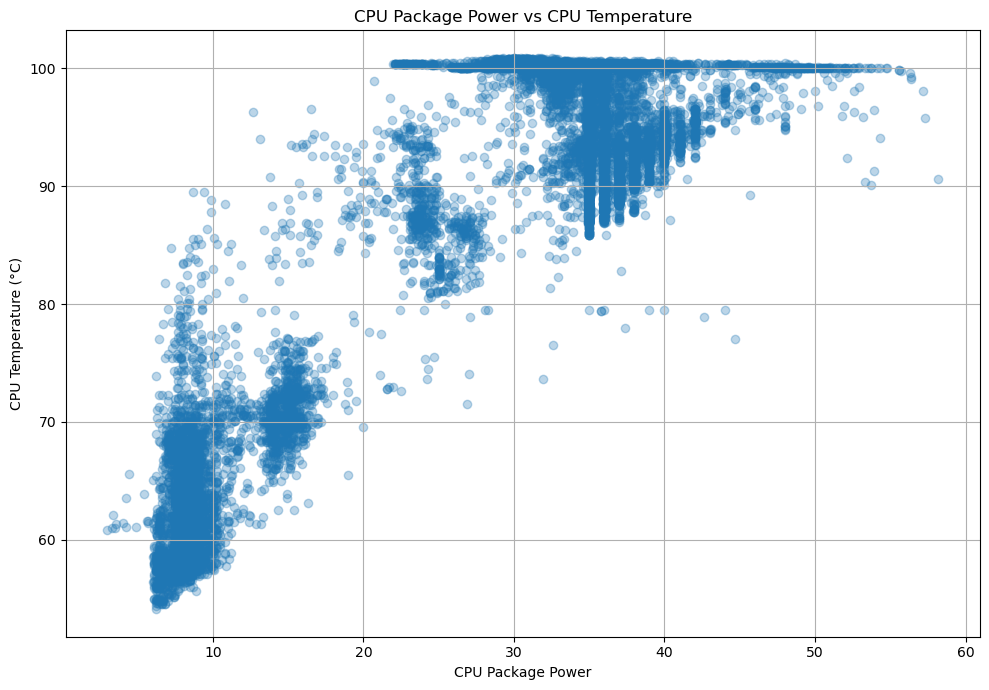

In [31]:
plt.figure(figsize=(10, 7))

plt.scatter(
    merged["cpuPackagePower"],
    merged["cpuTemperature"],
    alpha=0.3
)

plt.title("CPU Package Power vs CPU Temperature")
plt.xlabel("CPU Package Power")
plt.ylabel("CPU Temperature (°C)")
plt.grid(True)
plt.tight_layout()
plt.show()

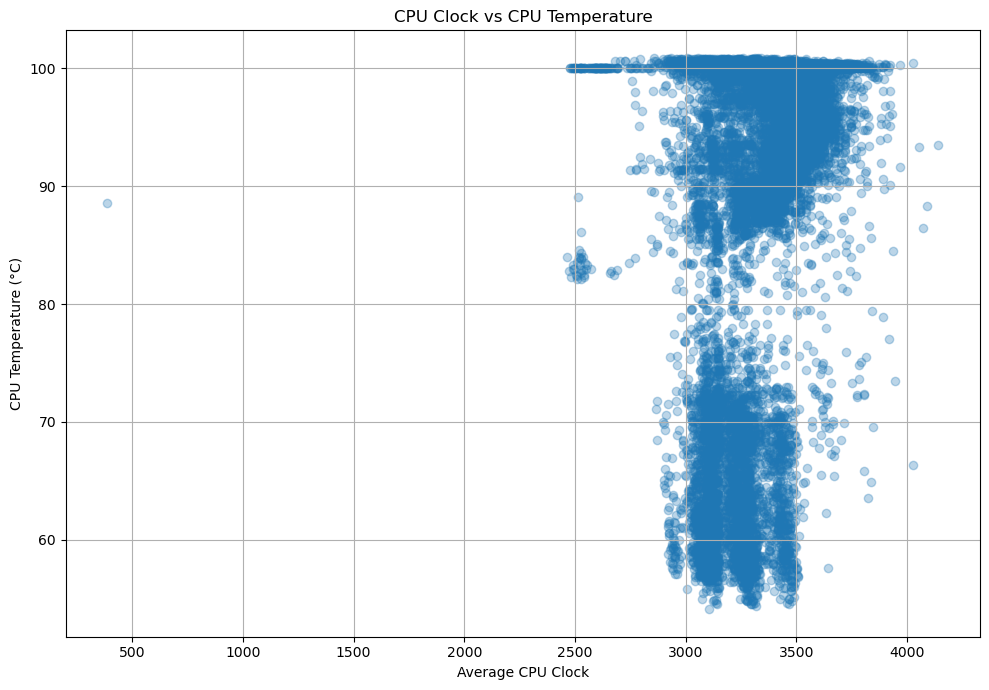

In [32]:
plt.figure(figsize=(10, 7))

plt.scatter(
    merged["cpuAverageClock"],
    merged["cpuTemperature"],
    alpha=0.3
)

plt.title("CPU Clock vs CPU Temperature")
plt.xlabel("Average CPU Clock")
plt.ylabel("CPU Temperature (°C)")
plt.grid(True)
plt.tight_layout()
plt.show()

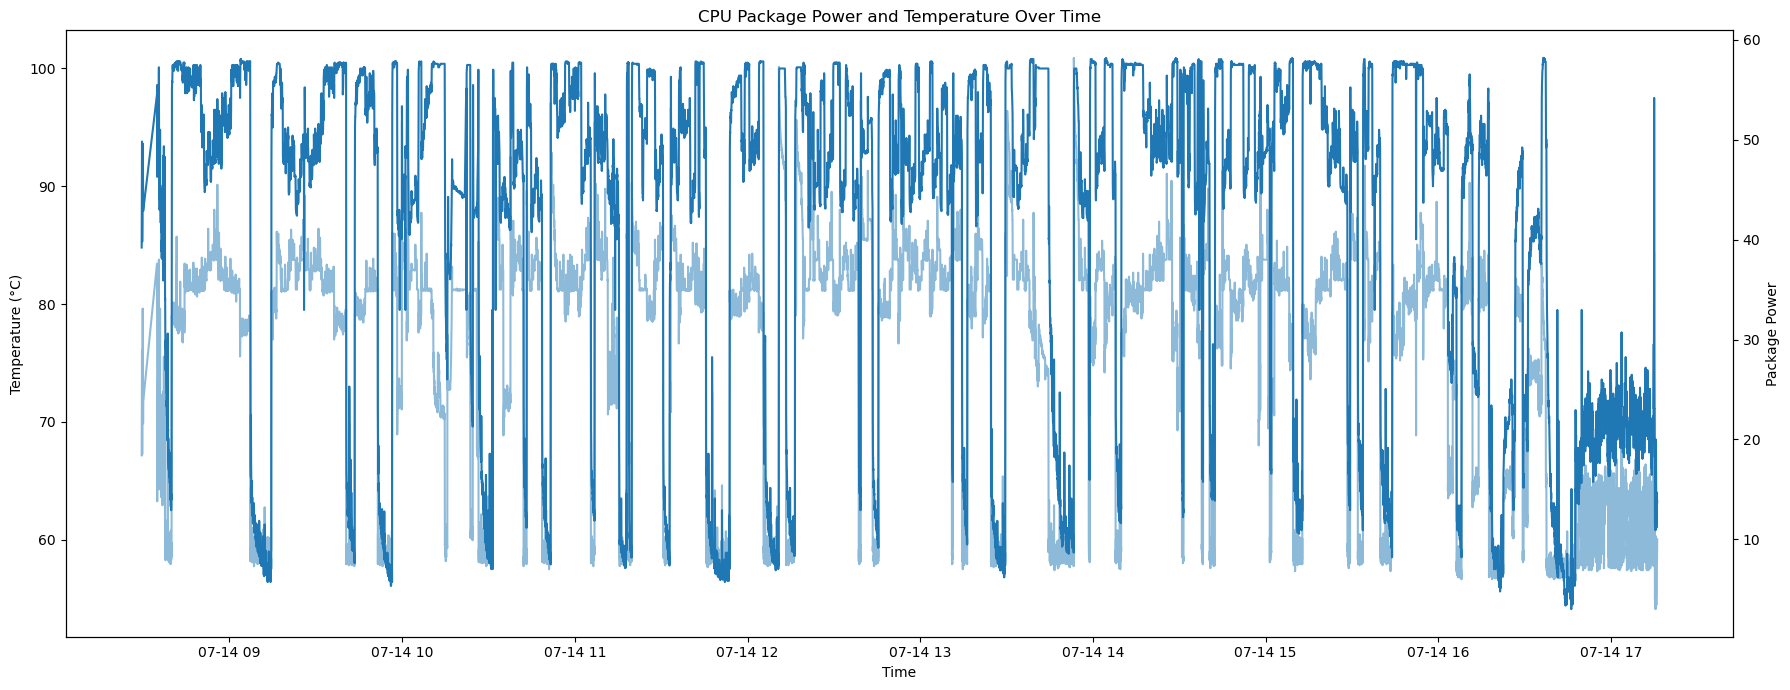

In [33]:
fig, ax1 = plt.subplots(figsize=(18, 7))

ax1.plot(
    merged["timestamp"],
    merged["cpuTemperature"],
    label="Temperature"
)

ax1.set_xlabel("Time")
ax1.set_ylabel("Temperature (°C)")

ax2 = ax1.twinx()

ax2.plot(
    merged["timestamp"],
    merged["cpuPackagePower"],
    alpha=0.5,
    label="Package Power"
)

ax2.set_ylabel("Package Power")

plt.title(
    "CPU Package Power and Temperature Over Time"
)

fig.tight_layout()
plt.show()

In [34]:
cooling = merged[
    merged["mode"]
    .astype(str)
    .str.contains("COOLING", case=False, na=False)
].copy()

print("Cooling samples:", len(cooling))

print(
    cooling["mode"].value_counts()
)

Cooling samples: 1331
mode
FINAL_COOLING                       294
COOLING_AFTER_RAMP                  149
COOLING_AFTER_GPU_CPU_COMBINED_3    149
COOLING_AFTER_GPU_CPU_COMBINED_1    148
COOLING_AFTER_CHAOS                 148
COOLING_AFTER_GPU_CPU_COMBINED_2    148
COOLING_AFTER_TRANSITION            148
COOLING_AFTER_MIXED                 147
Name: count, dtype: int64


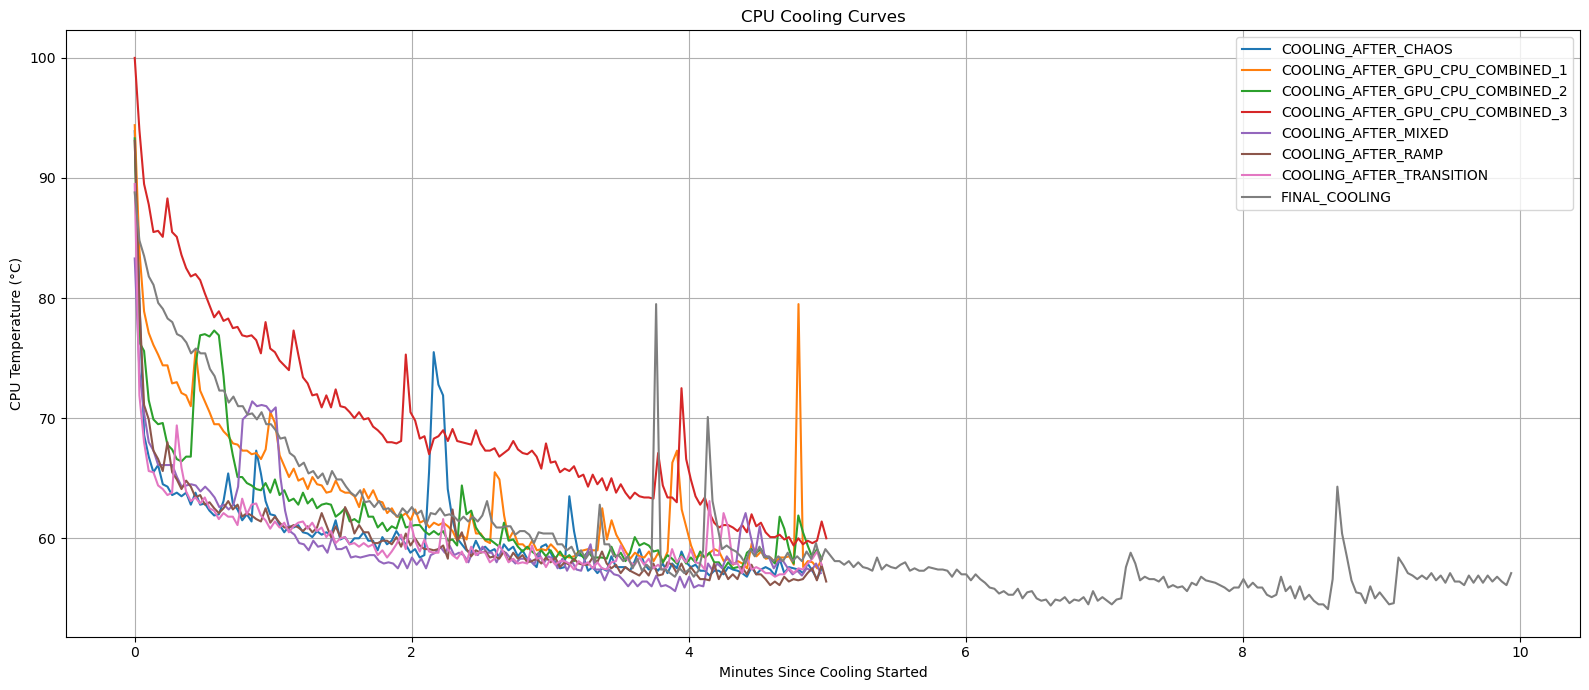

In [35]:
plt.figure(figsize=(16, 7))

for mode, group in cooling.groupby("mode"):

    group = group.sort_values("timestamp").copy()

    elapsed_minutes = (
        group["timestamp"] -
        group["timestamp"].min()
    ).dt.total_seconds() / 60

    plt.plot(
        elapsed_minutes,
        group["cpuTemperature"],
        label=mode
    )

plt.title("CPU Cooling Curves")
plt.xlabel("Minutes Since Cooling Started")
plt.ylabel("CPU Temperature (°C)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [36]:
cooling_summary = []

for mode, group in cooling.groupby("mode"):

    group = group.sort_values("timestamp")

    start_temp = group["cpuTemperature"].iloc[0]
    end_temp = group["cpuTemperature"].iloc[-1]

    duration_minutes = (
        group["timestamp"].iloc[-1] -
        group["timestamp"].iloc[0]
    ).total_seconds() / 60

    temperature_drop = (
        start_temp - end_temp
    )

    cooling_rate = (
        temperature_drop / duration_minutes
        if duration_minutes > 0
        else np.nan
    )

    cooling_summary.append({
        "mode": mode,
        "startTemperature": start_temp,
        "endTemperature": end_temp,
        "temperatureDrop": temperature_drop,
        "durationMinutes": duration_minutes,
        "coolingRatePerMinute": cooling_rate
    })

cooling_summary = pd.DataFrame(
    cooling_summary
)

display(cooling_summary)

,mode,startTemperature,endTemperature,temperatureDrop,durationMinutes,coolingRatePerMinute
0,COOLING_AFTER_CHAOS,93.9,57.5,36.4,4.959419,7.339570
1,COOLING_AFTER_GPU_CPU_COMBINED_1,94.4,58.3,36.1,4.960751,7.277124
2,COOLING_AFTER_GPU_CPU_COMBINED_2,93.3,58.3,35.0,4.959476,7.057197
3,COOLING_AFTER_GPU_CPU_COMBINED_3,100.0,60.0,40.0,4.993151,8.010973
4,COOLING_AFTER_MIXED,83.3,57.1,26.2,4.952746,5.289995
5,COOLING_AFTER_RAMP,93.1,56.4,36.7,4.992239,7.351411
6,COOLING_AFTER_TRANSITION,89.5,57.8,31.7,4.959592,6.391655
7,FINAL_COOLING,88.8,57.1,31.7,9.937395,3.189971


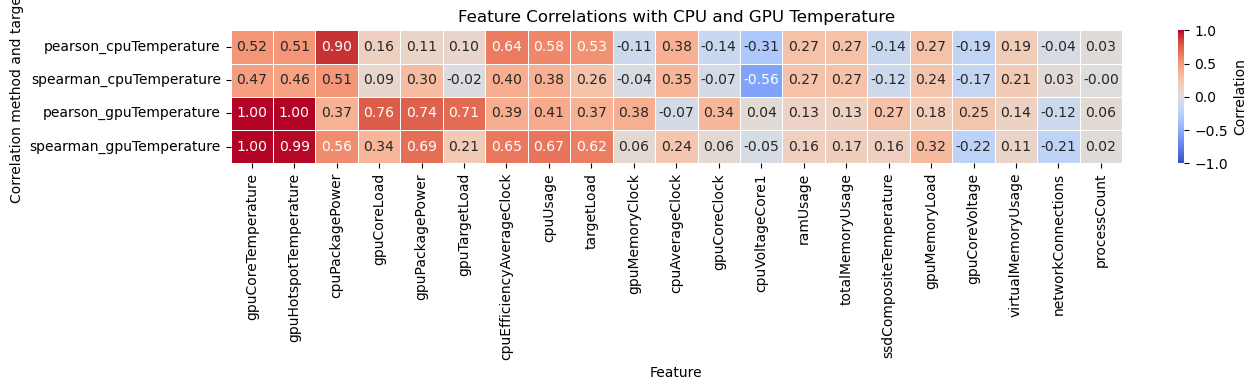

In [37]:
# Heatmap of all numeric features against CPU and GPU temperature.
heatmap_data = correlation_summary.drop(columns="max_abs_pearson").T
plt.figure(figsize=(max(12, len(heatmap_data.columns) * 0.65), 4))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, linewidths=0.4, cbar_kws={"label": "Correlation"})
plt.title("Feature Correlations with CPU and GPU Temperature")
plt.xlabel("Feature")
plt.ylabel("Correlation method and target")
plt.tight_layout()
plt.show()

In [38]:
# Sort by time
df = merged.sort_values("timestamp").reset_index(drop=True).copy()

# Your data is sampled roughly every 2 seconds
# 20 seconds ≈ 10 rows ahead
HORIZON_STEPS = 10

# Temperature 20 seconds into the future
df["futureTemperature"] = df["cpuTemperature"].shift(-HORIZON_STEPS)

# Exact target used conceptually by your model
df["delta_t"] = (
    df["futureTemperature"] - df["cpuTemperature"]
)

# Remove final rows where future temperature is unavailable
delta_df = df.dropna(subset=["delta_t"]).copy()

print("========== MANAN DELTA T ANALYSIS ==========")
print(delta_df["delta_t"].describe())

print("\nPercentage |Delta T| <= 1°C:")
print((delta_df["delta_t"].abs() <= 1).mean() * 100, "%")

print("\nPercentage Delta T == 0°C:")
print((delta_df["delta_t"] == 0).mean() * 100, "%")

print("\nPercentage Delta T > 4°C:")
print((delta_df["delta_t"] > 4).mean() * 100, "%")

print("\nMost common Delta T values:")
print(delta_df["delta_t"].value_counts().head(15))

========== MANAN DELTA T ANALYSIS ==========
count    15381.000000
mean        -0.017034
std          6.992154
min        -40.400000
25%         -1.000000
50%          0.000000
75%          0.900000
max         44.000000
Name: delta_t, dtype: float64

Percentage |Delta T| <= 1°C:
53.08497496911774 %

Percentage Delta T == 0°C:
10.207398738703596 %

Percentage Delta T > 4°C:
6.911124114166829 %

Most common Delta T values:
delta_t
 0.0    1570
-0.5     386
 0.1     384
-0.1     377
-0.2     352
 0.5     312
 0.2     307
 1.0     282
-1.0     282
-0.3     262
 0.1     233
 0.3     218
 1.5     202
-0.1     201
-0.4     174
Name: count, dtype: int64


In [39]:
mode_analysis = (
    delta_df
    .groupby("mode")["delta_t"]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
    .sort_values("count", ascending=False)
)

display(mode_analysis)

,count,mean,median,std,min,max
mode,,,,,,
MIXED,4365,0.019702,0.0,7.590527,-35.1,42.0
GPU_CPU_COMBINED,2210,0.007149,0.0,5.665839,-34.0,38.4
CHAOS,2186,-0.103888,-0.1,8.143119,-40.4,42.5
RAMP,2186,-0.052379,0.0,5.784898,-36.0,39.3
TRANSITION,2180,0.047661,0.0,7.844959,-33.7,42.5
UNASSIGNED,864,-0.012384,0.1,3.751556,-35.9,28.2
FINAL_COOLING,294,-0.497279,-0.5,3.566701,-20.5,20.0
COOLING_AFTER_GPU_CPU_COMBINED_3,149,-1.879195,-1.5,2.823149,-16.4,8.7
COOLING_AFTER_RAMP,149,1.826174,-0.5,11.114851,-29.0,44.0


In [40]:
for mode, group in delta_df.groupby("mode"):

    if len(group) < 10:
        continue

    print(f"\n========== {mode} ==========")
    print("Samples:", len(group))
    print("Mean Delta T:", group["delta_t"].mean())
    print("Median Delta T:", group["delta_t"].median())

    print(
        "% |Delta T| <= 1°C:",
        (group["delta_t"].abs() <= 1).mean() * 100
    )

    print(
        "% Delta T > 4°C:",
        (group["delta_t"] > 4).mean() * 100
    )


========== CHAOS ==========
Samples: 2186
Mean Delta T: -0.10388838060384267
Median Delta T: -0.09999999999999432
% |Delta T| <= 1°C: 48.26166514181153
% Delta T > 4°C: 7.548032936870998

========== COOLING_AFTER_CHAOS ==========
Samples: 148
Mean Delta T: -0.8371621621621621
Median Delta T: -0.5
% |Delta T| <= 1°C: 59.45945945945946
% Delta T > 4°C: 4.72972972972973

========== COOLING_AFTER_GPU_CPU_COMBINED_1 ==========
Samples: 148
Mean Delta T: 0.9709459459459455
Median Delta T: -0.8999999999999986
% |Delta T| <= 1°C: 37.83783783783784
% Delta T > 4°C: 9.45945945945946

========== COOLING_AFTER_GPU_CPU_COMBINED_2 ==========
Samples: 148
Mean Delta T: -0.983783783783784
Median Delta T: -0.6000000000000014
% |Delta T| <= 1°C: 52.02702702702703
% Delta T > 4°C: 4.72972972972973

========== COOLING_AFTER_GPU_CPU_COMBINED_3 ==========
Samples: 149
Mean Delta T: -1.8791946308724832
Median Delta T: -1.5
% |Delta T| <= 1°C: 33.557046979865774
% Delta T > 4°C: 1.342281879194631

==========

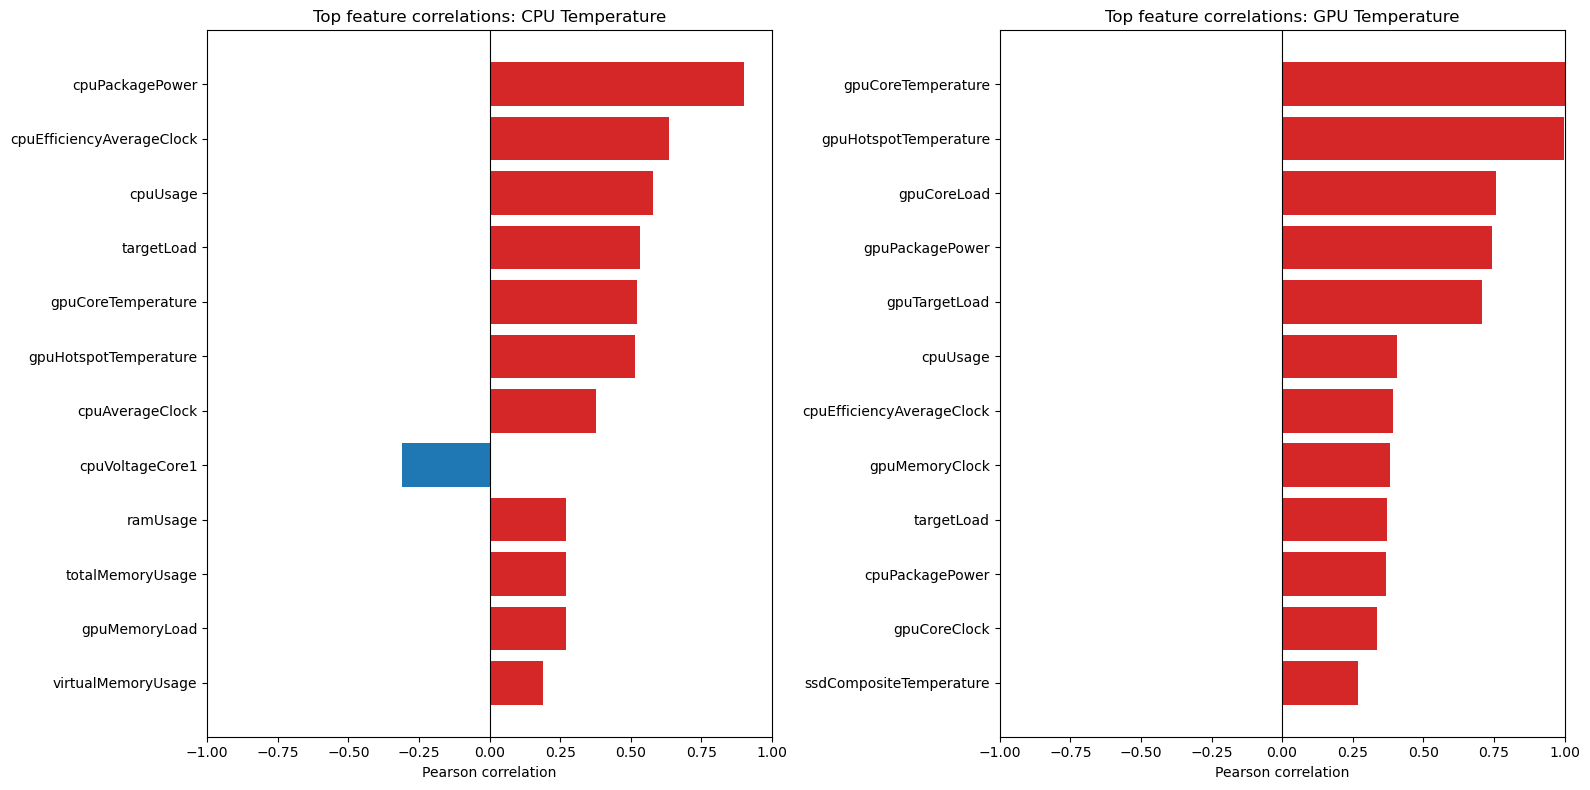

In [41]:
# Rank the strongest Pearson relationships for each temperature target.
ranked = correlation_summary.drop(columns="max_abs_pearson").copy()
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=False)

for ax, column, title in [
    (axes[0], "pearson_cpuTemperature", "CPU Temperature"),
    (axes[1], "pearson_gpuTemperature", "GPU Temperature"),
]:
    values = ranked[column].dropna().sort_values(key=lambda x: x.abs()).tail(12)
    colors = np.where(values >= 0, "tab:red", "tab:blue")
    ax.barh(values.index, values.values, color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlim(-1, 1)
    ax.set_title(f"Top feature correlations: {title}")
    ax.set_xlabel("Pearson correlation")

plt.tight_layout()
plt.show()

GPU_CPU_COMBINED workload samples: 2210


,cpuTemperature,gpuTemperature
targetLoad,0.320,0.185
gpuTargetLoad,0.441,0.832
cpuUsage,0.362,0.250
cpuPackagePower,0.742,0.043
gpuCoreLoad,0.416,0.914
gpuPackagePower,0.396,0.899
gpuCoreClock,0.436,0.848
gpuMemoryLoad,0.483,0.427


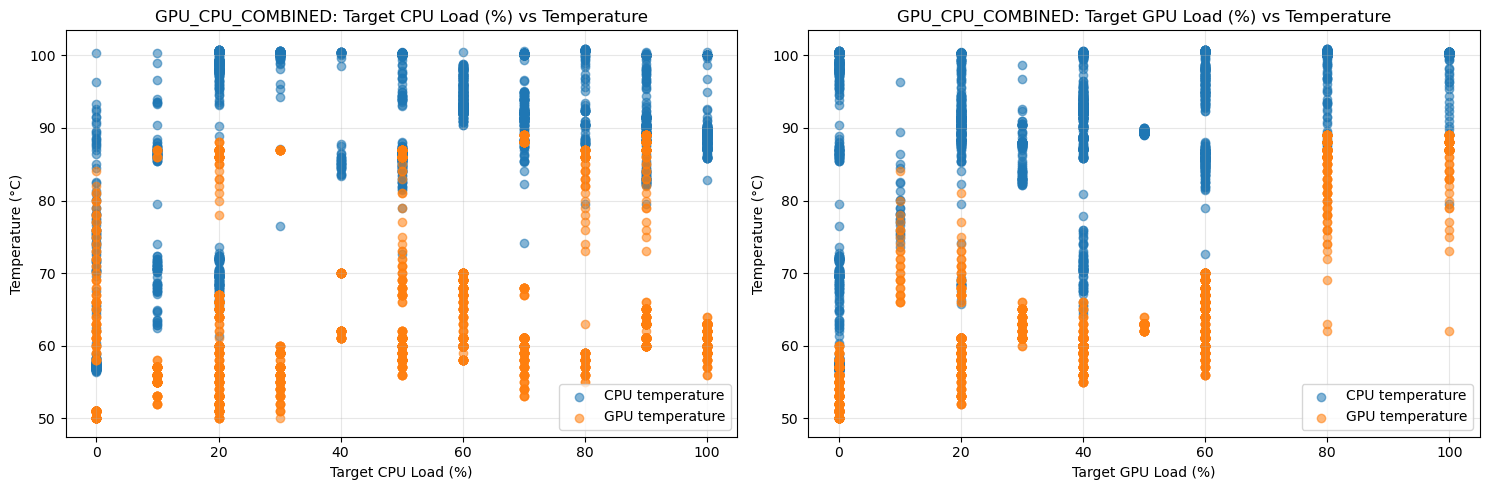

In [42]:
# GPU_CPU_COMBINED is analysed separately because gpuTargetLoad is only set there.
gpu_cpu_combined = merged[
    (merged["mode"] == "GPU_CPU_COMBINED") &
    (merged["eventType"] == "WORKLOAD_STEP")
].copy()

combined_features = [
    "targetLoad", "gpuTargetLoad", "cpuUsage", "cpuPackagePower",
    "gpuCoreLoad", "gpuPackagePower", "gpuCoreClock", "gpuMemoryLoad"
]
combined_features = [col for col in combined_features if col in gpu_cpu_combined]
combined_correlation = gpu_cpu_combined[
    combined_features + temperature_targets
].corr(method="pearson").loc[combined_features, temperature_targets]

print(f"GPU_CPU_COMBINED workload samples: {len(gpu_cpu_combined)}")
display(combined_correlation.round(3))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, x_col, x_label in [
    (axes[0], "targetLoad", "Target CPU Load (%)"),
    (axes[1], "gpuTargetLoad", "Target GPU Load (%)"),
]:
    scatter_data = gpu_cpu_combined.dropna(subset=[x_col])
    ax.scatter(scatter_data[x_col], scatter_data["cpuTemperature"], alpha=0.55,
               label="CPU temperature")
    ax.scatter(scatter_data[x_col], scatter_data["gpuTemperature"], alpha=0.55,
               label="GPU temperature")
    ax.set_title(f"GPU_CPU_COMBINED: {x_label} vs Temperature")
    ax.set_xlabel(x_label)
    ax.set_ylabel("Temperature (°C)")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# Correlation quantifies association, not causation; interpret it with the
# workload mode and the time-series plots above.